# Latent Timeline Graph — Temporal Relation Extraction

Kiến trúc kết hợp Allen's Interval Algebra với Graph Propagation ở mức document.

**Quy trình notebook:** (1) cấu hình → (2) dữ liệu → (3) mô hình → (4) loss & huấn luyện → (5) chạy 4 dataset × 3 seed → (6) tổng hợp kết quả → (7) ablation study → (8) trực quan latent timeline.

## 1. Imports, Device & Cấu hình

`DATASET_REGISTRY` khai báo 4 dataset; `BASE_CFG` chứa siêu tham số dùng chung (kể cả cờ ablation `abl_*`, mặc định = mô hình đầy đủ); `build_config(name)` sinh cfg cho từng dataset.

In [1]:
import os, re, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from tqdm import tqdm  # text-mode: tránh ghi widget-state vào .ipynb (lỗi commit >1MB trên Kaggle)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from IPython.display import display

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


IS_KAGGLE = os.path.exists('/kaggle/input')

# Mỗi dataset: data_root, tập nhãn CHUẨN, alias nhãn THÔ→CHUẨN.
DATASET_REGISTRY = {
    'tbd': dict(
        data_root='/kaggle/input/datasets/nhhongg/tbd-origin' if IS_KAGGLE else r'd:\Code KLTN\data\tbd',
        labels=['BEFORE', 'AFTER', 'INCLUDES', 'IS_INCLUDED', 'SIMULTANEOUS', 'VAGUE'],
        aliases={},
    ),
    'matres': dict(
        data_root='/kaggle/input/datasets/nhhongg/matres' if IS_KAGGLE else r'd:\Code KLTN\data\matres',
        labels=['BEFORE', 'AFTER', 'EQUAL', 'VAGUE'],
        aliases={},
    ),
    'tddman': dict(
        data_root='/kaggle/input/datasets/nhhongg/tddman' if IS_KAGGLE else r'd:\Code KLTN\data\tddman',
        labels=['BEFORE', 'AFTER', 'INCLUDES', 'IS_INCLUDED', 'SIMULTANEOUS'],
        aliases={'B': 'BEFORE', 'A': 'AFTER', 'I': 'INCLUDES', 'II': 'IS_INCLUDED', 'S': 'SIMULTANEOUS'},
    ),
    'tddauto': dict(
        data_root='/kaggle/input/datasets/nhhongg/tddauto' if IS_KAGGLE else r'd:\Code KLTN\data\tddauto',
        labels=['BEFORE', 'AFTER', 'INCLUDES', 'IS_INCLUDED', 'SIMULTANEOUS'],
        aliases={'B': 'BEFORE', 'A': 'AFTER', 'I': 'INCLUDES', 'II': 'IS_INCLUDED', 'S': 'SIMULTANEOUS'},
    ),
}

# Siêu tham số dùng chung cho mọi dataset / mọi lần chạy.
BASE_CFG = dict(
    save_dir       = '/kaggle/working' if IS_KAGGLE else r'd:\Code KLTN',
    auto_split_dev = True,    # dataset không có dev → tách từ train theo document
    dev_ratio      = 0.1,
    split_seed     = 42,

    model_name     = 'bert-base-uncased',
    max_length     = 512,
    window         = 512,
    stride         = 128,
    max_doc_tokens = 0,       # 0 = encode trọn document; >0 = van an toàn VRAM

    hidden_size    = 768,
    rel_dim        = 256,
    geo_pred_dim   = 6,
    phi_dim        = 10,
    align_dim      = 32,
    graph_layers   = 2,
    drop_edge      = 0.15,
    graph_topk     = 15,
    graph_dense    = True,    # True = propagation trên MỌI cặp i≠j (m*(m-1)); False = chỉ cặp đã gán nhãn
    dropout        = 0.1,
    eps            = 0.05,

    lam_align      = 1,
    lam_reg        = 0.005,
    align_stopgrad = 'phi',          # None | 'phi' | 'g'
    use_class_weights     = True,
    class_weight_power    = 0.8,
    class_weight_clip_max = 2.5,

    lr             = 2e-5,
    wd             = 0.01,
    total_epochs      = 100,
    graph_start_epoch = 10,
    f1_patience       = 10,
    min_f1_delta      = 0.001,
    warmup_ratio   = 0.1,
    accum_steps    = 4,

    # ── Ablation flags: mặc định = mô hình ĐẦY ĐỦ (giữ nguyên kiến trúc) ──
    abl_use_graph       = True,   # False = bỏ graph propagation
    abl_relation_branch = True,   # False = bỏ nhánh z_rel
    abl_event_branch    = True,   # False = bỏ nhánh z_geo (Allen)
    abl_align_loss      = True,   # False = tắt L_align
)


def build_config(dataset_name, **overrides):
    """Sinh cfg đầy đủ cho một dataset = BASE_CFG + thông tin nhãn + overrides.
    Cấu trúc nhãn được nhúng vào cfg để mọi hàm chỉ đọc từ cfg (không dùng global)."""
    ds = DATASET_REGISTRY[dataset_name]
    labels = list(ds['labels'])
    label_map = {l: i for i, l in enumerate(labels)}
    cfg = dict(BASE_CFG)
    cfg.update(
        dataset        = dataset_name,
        data_root      = ds['data_root'],
        labels         = labels,
        num_classes    = len(labels),
        label_map      = label_map,
        id2label       = {i: l for l, i in label_map.items()},
        label_aliases  = {k.upper(): v for k, v in ds['aliases'].items()},
        vague_id       = label_map.get('VAGUE', -1),
        eval_label_ids = [i for i, l in enumerate(labels) if l != 'VAGUE'],  # F1 loại VAGUE
    )
    cfg.update(overrides)
    return cfg

Device: cuda


## 2. Data Pipeline

Tokenize trọn document (không truncation), map char-span của event → token-span và gom các cặp đã gán nhãn. `prepare_dataset(name)` trả về *bundle* (docs + loaders + class weights) tái sử dụng cho mọi seed.

In [2]:
tokenizer = AutoTokenizer.from_pretrained(BASE_CFG['model_name'])


def normalize_label(raw, cfg):
    s = str(raw).strip().upper()
    s = cfg['label_aliases'].get(s, s)
    return cfg['label_map'].get(s, -1)


def char_to_token_span(offsets, char_s, char_e):
    """Char span [char_s, char_e) → inclusive token span (index vào offsets)."""
    tok_s = tok_e = None
    for i, (ts, te) in enumerate(offsets):
        if ts == te:
            continue
        if te > char_s and ts < char_e:
            if tok_s is None:
                tok_s = i
            tok_e = i
    if tok_s is None:                       # fallback: token gần char_s nhất
        valid = [(i, ts) for i, (ts, te) in enumerate(offsets) if ts != te]
        tok_s = tok_e = (min(valid, key=lambda x: abs(x[1] - char_s))[0] if valid else 0)
    return tok_s, tok_e


def preprocess_documents(df, cfg):
    """Gom theo `text`, tokenize trọn vẹn (không truncation), map char-span của
    event → token-span và thu các cặp đã gán nhãn. Encoder dùng cửa sổ trượt khi
    forward nên không mất event ở document dài."""
    samples, truncated = [], 0
    for doc_text, grp in tqdm(df.groupby('text', sort=False), desc='Docs', leave=False):
        doc_id = grp.iloc[0]['document_id']

        events = {}                                     # full_eid → (char_s, char_e)
        for _, row in grp.iterrows():
            for eid, cs, ce in [
                (row['entity1_id'], int(row['entity1_start']), int(row['entity1_end'])),
                (row['entity2_id'], int(row['entity2_start']), int(row['entity2_end'])),
            ]:
                events.setdefault(f'{doc_id}_{eid}', (cs, ce))

        event_ids = list(events.keys())
        e2idx     = {eid: i for i, eid in enumerate(event_ids)}

        enc = tokenizer(doc_text, add_special_tokens=False, return_offsets_mapping=True)
        input_ids, offsets = enc['input_ids'], enc['offset_mapping']
        if cfg['max_doc_tokens'] and len(input_ids) > cfg['max_doc_tokens']:
            input_ids = input_ids[:cfg['max_doc_tokens']]
            offsets   = offsets[:cfg['max_doc_tokens']]
            truncated += 1
        seq_len = len(input_ids)

        token_spans = []
        for eid in event_ids:
            cs, ce = events[eid]
            ts, te = char_to_token_span(offsets, cs, ce)
            ts = max(0, min(ts, seq_len - 1))
            te = max(ts, min(te, seq_len - 1))
            token_spans.append((ts, te))

        pairs = []
        for _, row in grp.iterrows():
            label = normalize_label(row['label'], cfg)
            if label == -1:
                continue
            i = e2idx[f'{doc_id}_{row["entity1_id"]}']
            j = e2idx[f'{doc_id}_{row["entity2_id"]}']
            pairs.append((i, j, label))
        if not pairs:
            continue

        samples.append(dict(
            doc_id=doc_id,
            input_ids=torch.tensor(input_ids, dtype=torch.long),
            event_ids=event_ids,
            token_spans=token_spans,
            pairs=pairs,
            num_events=len(event_ids),
            seq_len=seq_len,
        ))
    print(f'  → {len(samples)} nhóm | {sum(len(s["pairs"]) for s in samples)} pairs'
          + (f' | {truncated} nhóm bị cắt' if truncated else ''))
    return samples

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [3]:
def resolve_data_root(cfg):
    """Trả về thư mục chứa CSV; nếu data_root khai báo không tồn tại thì tự dò
    dưới /kaggle/input theo tên dataset."""
    root = Path(cfg['data_root'])
    if root.exists():
        return root
    key = re.sub(r'[^a-z0-9]', '', cfg['dataset'].lower())
    for base in [Path('/kaggle/input'), Path('.'), Path('data'), Path('..')]:
        if not base.exists():
            continue
        for p in base.rglob('train.csv'):
            par = re.sub(r'[^a-z0-9]', '', p.parent.name.lower())
            if key and (key in par or par in key):
                return p.parent
    raise FileNotFoundError(f"Không tìm thấy dữ liệu cho '{cfg['dataset']}' (data_root={cfg['data_root']})")


def load_splits(data_dir):
    folder = Path(data_dir)
    dfs = {}
    for fpath in (sorted(folder.glob('*.csv')) or sorted(folder.glob('**/*.csv'))):
        dfs[fpath.stem.lower()] = pd.read_csv(fpath)
    return dfs


class DocumentDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]


def compute_class_weights(docs, cfg):
    """class weight = balanced^power, clip max — hạ lớp đa số, nâng lớp hiếm."""
    counts = np.zeros(cfg['num_classes'], dtype=np.float64)
    for d in docs:
        for (_, _, lab) in d['pairs']:
            counts[lab] += 1
    counts = np.maximum(counts, 1.0)
    if cfg['use_class_weights']:
        w = (counts.sum() / (len(counts) * counts)) ** cfg['class_weight_power']
        w = np.clip(w, 0.0, cfg['class_weight_clip_max'])
    else:
        w = np.ones(cfg['num_classes'])
    return counts.astype(int), torch.tensor(w, dtype=torch.float)


def prepare_dataset(dataset_name, verbose=True):
    """Nạp + tiền xử lý một dataset → 'bundle' dùng lại cho MỌI seed
    (tiền xử lý không phụ thuộc seed train): cfg, docs, loaders, class_weights."""
    cfg = build_config(dataset_name)
    dfs = load_splits(resolve_data_root(cfg))

    split_map = {}
    for k in dfs:
        if 'train' in k:               split_map['train'] = k
        elif 'dev' in k or 'val' in k: split_map['dev']   = k
        elif 'test' in k:              split_map['test']  = k

    train_docs = preprocess_documents(dfs[split_map['train']], cfg)
    test_docs  = preprocess_documents(dfs[split_map['test']], cfg)
    if 'dev' in split_map:
        dev_docs = preprocess_documents(dfs[split_map['dev']], cfg)
    elif cfg['auto_split_dev']:                          # vd MATRES: tách dev theo nhóm
        rng = random.Random(cfg['split_seed'])
        order = list(range(len(train_docs))); rng.shuffle(order)
        n_dev = max(1, int(cfg['dev_ratio'] * len(train_docs)))
        dev_set = set(order[:n_dev])
        dev_docs   = [d for i, d in enumerate(train_docs) if i in dev_set]
        train_docs = [d for i, d in enumerate(train_docs) if i not in dev_set]
    else:
        dev_docs = []

    counts, class_weights = compute_class_weights(train_docs, cfg)
    mk = lambda docs, sh: DataLoader(DocumentDataset(docs), batch_size=1, shuffle=sh,
                                     collate_fn=lambda b: b[0])
    bundle = dict(
        cfg=cfg,
        train_docs=train_docs, dev_docs=dev_docs, test_docs=test_docs,
        train_loader=mk(train_docs, True),
        dev_loader=mk(dev_docs, False),
        test_loader=mk(test_docs, False),
        class_weights=class_weights, class_counts=counts,
    )
    if verbose:
        print(f'[{dataset_name}] train={len(train_docs)} dev={len(dev_docs)} '
              f'test={len(test_docs)} docs | labels={cfg["labels"]}')
        print('  class counts :', {cfg['id2label'][i]: int(c) for i, c in enumerate(counts)})
    return bundle

## 3. Kiến trúc mô hình

**3.1** Thành phần cơ bản (event time head, geometry, relation encoder) · **3.2** Graph propagation · **3.3** Decoders (Allen + Relation) · **3.4** `LatentTimelineGraphModel`.

Quan hệ `h_ij = FFN([z_i; z_j])`; fusion `logits = z_rel + α·z_geo`. Các cờ `abl_*` chỉ dùng cho ablation, mặc định giữ nguyên mô hình đầy đủ.

In [4]:
# 3.1 Thành phần cơ bản

class EventTimeHead(nn.Module):
    """z (m, H) → interval (s, t) với t = s + softplus(d) + eps."""
    def __init__(self, hidden_size, eps=0.05):
        super().__init__()
        self.fs  = nn.Linear(hidden_size, 1)
        self.fd  = nn.Linear(hidden_size, 1)
        self.eps = eps

    def forward(self, z):
        s = self.fs(z).squeeze(-1)
        d = F.softplus(self.fd(z)).squeeze(-1) + self.eps
        return s, s + d


class GeometryComputer(nn.Module):
    """Interval (s, t) + cặp (pi, pj) → phi_ij (10 đặc trưng hình học)."""
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, s, t, pi, pj):
        si = s[pi]; ti = t[pi]; sj = s[pj]; tj = t[pj]
        di = ti - si; dj = tj - sj; eps = self.eps
        overlap = torch.clamp(torch.minimum(ti, tj) - torch.maximum(si, sj), min=0.0)
        return torch.stack([
            sj - si,                                      # delta_s
            tj - ti,                                      # delta_t
            sj - ti,                                      # gap
            si - tj,                                      # rev_gap
            overlap,                                      # overlap
            overlap / (torch.minimum(di, dj) + eps),      # ov_ratio
            torch.minimum(sj - si, ti - tj),              # cont_ij (i chứa j)
            torch.minimum(si - sj, tj - ti),              # cont_ji (j chứa i)
            torch.log((di + eps) / (dj + eps)),           # dur_rat
            -(torch.abs(si - sj) + torch.abs(ti - tj)),   # eq_score
        ], dim=-1)


class RelationEncoder(nn.Module):
    """h_ij = FFN([z_i; z_j]) (mục 5)."""
    def __init__(self, hidden_size, rel_dim, dropout=0.1):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size * 2, rel_dim * 2),
            nn.LayerNorm(rel_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(rel_dim * 2, rel_dim),
            nn.LayerNorm(rel_dim),
        )

    def forward(self, zi, zj):
        return self.ffn(torch.cat([zi, zj], dim=-1))


class RelativeGeometryHead(nn.Module):
    """h_ij (rel_dim) → g_ij (geo_pred_dim) — relative geometry dự đoán."""
    def __init__(self, rel_dim, geo_pred_dim=6):
        super().__init__()
        self.head = nn.Linear(rel_dim, geo_pred_dim)

    def forward(self, h):
        return self.head(h)

In [5]:
# 3.2 Graph propagation

class GraphPropagationLayer(nn.Module):
    """Một vòng Latent Timeline Graph (mục 7-8):
      • Node v_i = [z_i; s_i; t_i; d_i]; edge thêm sim_sem=cos(z_i,z_j), sim_time=exp(-|s_j-s_i|).
      • EdgeUpdate → GeometryHead → message theo cạnh có hướng (nguồn → đích).
      • DropEdge (chỉ train) → Top-K theo attention → softmax theo node ĐÍCH → GRU NodeUpdate.
    Hai chế độ cạnh (tham số `dense` của forward):
      • dense=False: nhận cặp candidate, tự ghép cạnh xuôi (j→i) + ngược (i→j, dùng phi_rev).
      • dense=True : (pi, pj) đã là TẬP CẠNH CÓ HƯỚNG ĐẦY ĐỦ → mỗi cạnh tự dùng phi của nó.
    """
    def __init__(self, H, R, G, P, dropout=0.1, drop_edge=0.0, graph_topk=0):
        super().__init__()
        self.drop_edge  = drop_edge
        self.graph_topk = graph_topk

        Vd = H + 3        # node augmented: z (H) + [s, t, d]
        Sd = 2            # sim_sem, sim_time

        self.edge_ffn  = nn.Sequential(
            nn.Linear(R + 2*Vd + G + P + Sd, R * 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(R * 2, R),
        )
        self.edge_norm = nn.LayerNorm(R)
        self.geo_head  = RelativeGeometryHead(R, G)

        self.msg_ffn    = nn.Sequential(
            nn.Linear(Vd + R + G + P + Sd, H), nn.GELU(), nn.Dropout(dropout),
        )
        self.attn_score = nn.Linear(Vd + R + G + P + Sd, 1)
        self.gru        = nn.GRUCell(H, H)

    @staticmethod
    def _topk_keep_scores(scores, dst, K):
        """Giữ K cạnh điểm cao nhất cho MỖI node đích; cạnh khác → -inf (loại ở softmax)."""
        E = scores.size(0)
        order  = torch.argsort(scores, descending=True)
        _, o2  = torch.sort(dst[order], stable=True)
        perm   = order[o2]
        dperm  = dst[perm]
        ar     = torch.arange(E, device=scores.device)
        is_new = torch.ones(E, dtype=torch.bool, device=scores.device)
        is_new[1:] = dperm[1:] != dperm[:-1]
        gstart = torch.cummax(torch.where(is_new, ar, torch.zeros_like(ar)), dim=0).values
        pos    = ar - gstart
        keep   = torch.zeros(E, dtype=torch.bool, device=scores.device)
        keep[perm] = pos < K
        return scores.masked_fill(~keep, float('-inf'))

    def forward(self, z, s, t, h, g, phi, phi_rev, pi, pj, m, dense=False):
        """phi = Geometry(I_i, I_j) của cạnh (nguồn pj → đích pi).
        dense=False: ghép thêm cạnh ngược (i→j) với phi_rev để có đồ thị hai chiều.
        dense=True : (pi, pj) đã đủ cả hai hướng → KHÔNG ghép phi_rev."""
        Hd = z.size(-1)

        d  = t - s
        v  = torch.cat([z, s.unsqueeze(-1), t.unsqueeze(-1), d.unsqueeze(-1)], dim=-1)  # (m, H+3)
        vi = v[pi]; vj = v[pj]

        sim_sem  = F.cosine_similarity(z[pi], z[pj], dim=-1)
        sim_time = torch.exp(-torch.abs(s[pj] - s[pi]))
        sim      = torch.stack([sim_sem, sim_time], dim=-1)        # (E_in, 2)

        # EdgeUpdate + geometry mới (trên từng cạnh đầu vào)
        h_new = self.edge_norm(h + self.edge_ffn(torch.cat([h, vi, vj, g, phi, sim], dim=-1)))
        g_new = self.geo_head(h_new)

        if dense:                          # cạnh có hướng đã đầy đủ: nguồn pj → đích pi
            src, dst = pj, pi
            e_h, e_g, e_phi, e_sim = h_new, g_new, phi, sim
        else:                              # ghép cạnh xuôi (j→i) + ngược (i→j)
            src   = torch.cat([pj, pi], dim=0)
            dst   = torch.cat([pi, pj], dim=0)
            e_h   = torch.cat([h_new, h_new], dim=0)
            e_g   = torch.cat([g_new, g_new], dim=0)
            e_phi = torch.cat([phi, phi_rev], dim=0)
            e_sim = torch.cat([sim, sim], dim=0)
        E = src.size(0)

        if self.training and self.drop_edge > 0:                  # DropEdge
            keep = torch.rand(E, device=z.device) >= self.drop_edge
            src, dst = src[keep], dst[keep]
            e_h, e_g, e_phi, e_sim = e_h[keep], e_g[keep], e_phi[keep], e_sim[keep]

        msg_in = torch.cat([v[src], e_h, e_g, e_phi, e_sim], dim=-1)
        msgs   = self.msg_ffn(msg_in)                             # (E, H)
        scores = self.attn_score(msg_in).squeeze(-1)              # (E,)

        if self.graph_topk and self.graph_topk > 0:
            scores = self._topk_keep_scores(scores, dst, self.graph_topk)

        # attention softmax theo node đích
        node_max = torch.full((m,), float('-inf'), device=z.device)
        node_max.scatter_reduce_(0, dst, scores, reduce='amax', include_self=True)
        exp_s   = torch.exp(scores - node_max[dst])
        sum_exp = torch.zeros(m, device=z.device).scatter_add_(0, dst, exp_s)
        attn_w  = exp_s / (sum_exp[dst] + 1e-9)

        z_agg = torch.zeros(m, Hd, device=z.device)
        z_agg.scatter_add_(0, dst.unsqueeze(-1).expand(-1, Hd), attn_w.unsqueeze(-1) * msgs)

        z_new = self.gru(z_agg, z)                                # NodeUpdate (mục 8.4)
        return z_new, h_new, g_new

In [6]:
# 3.3 Decoders

class AllenDecoder(nn.Module):
    """Geometric logits theo đúng tập nhãn của dataset (mục 10). Mỗi nhãn có công
    thức hình học riêng từ interval; VAGUE dùng head học được. Thứ tự cột khớp `labels`.
      BEFORE: s_j-t_i · AFTER: s_i-t_j · INCLUDES: min(s_j-s_i, t_i-t_j)
      IS_INCLUDED: min(s_i-s_j, t_j-t_i) · EQUAL: -(|s_i-s_j|+|t_i-t_j|)
      SIMULTANEOUS: ov_ratio - gamma·bdiff · VAGUE: head([phi; g])
    """
    def __init__(self, phi_dim, geo_pred_dim, labels, eps=1e-6):
        super().__init__()
        self.labels     = list(labels)
        self.eps        = eps
        self.gamma      = nn.Parameter(torch.tensor(0.5))
        self.vague_head = nn.Linear(phi_dim + geo_pred_dim, 1)

    def forward(self, si, ti, sj, tj, phi, g):
        di = ti - si; dj = tj - sj; eps = self.eps
        overlap  = torch.clamp(torch.minimum(ti, tj) - torch.maximum(si, sj), min=0.0)
        ov_ratio = overlap / (torch.minimum(di, dj) + eps)
        bdiff    = torch.abs(si - sj) + torch.abs(ti - tj)
        col = {
            'BEFORE':       sj - ti,
            'AFTER':        si - tj,
            'INCLUDES':     torch.minimum(sj - si, ti - tj),
            'IS_INCLUDED':  torch.minimum(si - sj, tj - ti),
            'EQUAL':        -bdiff,
            'SIMULTANEOUS': ov_ratio - torch.abs(self.gamma) * bdiff,
            'VAGUE':        self.vague_head(torch.cat([phi, g], dim=-1)).squeeze(-1),
        }
        return torch.stack([col[l] for l in self.labels], dim=-1)   # (P, num_classes)


class RelationDecoder(nn.Module):
    """[h; g; phi; cos_sim] → z_rel (num_classes,)."""
    def __init__(self, rel_dim, phi_dim, geo_pred_dim, num_classes, dropout=0.1):
        super().__init__()
        in_dim = rel_dim + phi_dim + geo_pred_dim + 1
        self.ffn = nn.Sequential(
            nn.Linear(in_dim, rel_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(rel_dim, num_classes),
        )

    def forward(self, h, g, phi, sim_sem):
        return self.ffn(torch.cat([h, g, phi, sim_sem.unsqueeze(-1)], dim=-1))

In [7]:
# 3.4 LatentTimelineGraphModel

class LatentTimelineGraphModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        H, R, G, P = cfg['hidden_size'], cfg['rel_dim'], cfg['geo_pred_dim'], cfg['phi_dim']
        NC, L, dr  = cfg['num_classes'], cfg['graph_layers'], cfg['dropout']
        self.cfg = cfg

        self.encoder   = AutoModel.from_pretrained(cfg['model_name'])
        self.drop      = nn.Dropout(dr)
        self.span_attn = nn.Linear(H, 1)                                      # attention pooling (mục 3)
        self.span_proj = nn.Sequential(nn.Linear(H, H), nn.LayerNorm(H), nn.GELU())

        self.event_time   = EventTimeHead(H, eps=cfg['eps'])
        self.rel_enc      = RelationEncoder(H, R, dropout=dr)
        self.geo_head     = RelativeGeometryHead(R, G)
        self.geo_computer = GeometryComputer()
        self.graph_layers = nn.ModuleList([
            GraphPropagationLayer(H, R, G, P, dropout=dr,
                                  drop_edge=cfg.get('drop_edge', 0.0),
                                  graph_topk=cfg.get('graph_topk', 0))
            for _ in range(L)
        ])

        self.allen_decoder = AllenDecoder(P, G, cfg['labels'])
        self.rel_decoder   = RelationDecoder(R, P, G, NC, dropout=dr)

        # Fusion (mục 12): chuẩn hoá z_geo theo lớp + alpha[c] cân từng lớp.
        self.geo_norm = nn.LayerNorm(NC, elementwise_affine=False)
        self.alpha    = nn.Parameter(torch.full((NC,), 0.4))

        # Alignment (mục 13.2): P_g, P_phi đưa g (R^6), phi (R^10) về chung R^d.
        d_align = cfg.get('align_dim', 32)
        self.align_g   = nn.Sequential(nn.LayerNorm(G), nn.Linear(G, d_align))
        self.align_phi = nn.Sequential(nn.LayerNorm(P), nn.Linear(P, d_align))

    def _encode_document(self, input_ids):
        """Sliding-window encoder phủ trọn document (kể cả > 512 token).
        input_ids: (T,) token nội dung. Trả về (T, H); vùng bị nhiều cửa sổ phủ → trung bình."""
        win    = self.cfg['window'] - 2
        stride = self.cfg['stride']
        step   = max(1, win - stride)
        bos = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.cls_token_id
        eos = tokenizer.eos_token_id if tokenizer.eos_token_id is not None else tokenizer.sep_token_id
        pad = tokenizer.pad_token_id

        ids = input_ids.tolist()
        T   = len(ids)
        windows, spans, start = [], [], 0
        while start < T:
            end = min(start + win, T)
            windows.append(ids[start:end]); spans.append((start, end))
            if end == T:
                break
            start += step

        maxw = max(len(w) for w in windows) + 2
        batch_ids, masks = [], []
        for w in windows:
            seq = [bos] + w + [eos]
            p   = maxw - len(seq)
            masks.append([1] * len(seq) + [0] * p)
            batch_ids.append(seq + [pad] * p)
        batch_ids = torch.tensor(batch_ids, device=DEVICE)
        masks     = torch.tensor(masks, device=DEVICE)

        out = self.encoder(input_ids=batch_ids, attention_mask=masks).last_hidden_state  # (W, maxw, H)
        Hd  = out.size(-1)
        acc = torch.zeros(T, Hd, device=DEVICE, dtype=out.dtype)
        cnt = torch.zeros(T, 1,  device=DEVICE, dtype=out.dtype)
        for k, (sp, ep) in enumerate(spans):
            Lw = ep - sp
            acc[sp:ep] += out[k, 1:1 + Lw]
            cnt[sp:ep] += 1
        return acc / cnt.clamp(min=1.0)

    def _span_pool(self, H_seq, token_spans):
        """Attention pooling trên token mỗi span (mục 3): alpha=softmax(w_a·h); z=sum alpha·h."""
        vecs = []
        for ts, te in token_spans:
            span = H_seq[ts: te + 1]
            if span.size(0) == 0:
                span = H_seq[ts: ts + 1]
            alpha = torch.softmax(self.span_attn(span).squeeze(-1), dim=0)
            vecs.append((alpha.unsqueeze(-1) * span).sum(0))
        return torch.stack(vecs, dim=0)

    @staticmethod
    def _dense_edges(m):
        """Tập cạnh CÓ HƯỚNG ĐẦY ĐỦ: mọi (gi, gj) với gi ≠ gj  → m*(m-1) cạnh (vector hoá)."""
        idx  = torch.arange(m, device=DEVICE)
        gi   = idx.repeat_interleave(m)
        gj   = idx.repeat(m)
        keep = gi != gj                       # loại đường chéo gi == gj
        return gi[keep], gj[keep]

    def forward(self, batch, use_graph=True):
        """Returns: logits (P, NC), s (m,), t (m,), g (P, G), phi (P, 10) — đều cho cặp candidate."""
        input_ids   = batch['input_ids'].to(DEVICE)
        token_spans = batch['token_spans']
        pairs       = batch['pairs']
        m           = batch['num_events']

        H_seq = self.drop(self._encode_document(input_ids))          # (T, H)
        z = self.span_proj(self._span_pool(H_seq, token_spans))      # (m, H)
        s, t = self.event_time(z)

        pi = torch.tensor([p[0] for p in pairs], dtype=torch.long, device=DEVICE)
        pj = torch.tensor([p[1] for p in pairs], dtype=torch.long, device=DEVICE)

        # Quan hệ cho RIÊNG cặp candidate (dùng khi không bật graph, hoặc graph thưa).
        h   = self.rel_enc(z[pi], z[pj])     # (P, R)
        g   = self.geo_head(h)               # (P, G)

        if use_graph and self.cfg.get('graph_dense', True):
            # ── Dense: propagation trên TOÀN BỘ cạnh i≠j; readout gather về candidate ──
            gi, gj = self._dense_edges(m)                            # (E,) E = m*(m-1)
            pos = torch.full((m * m,), -1, dtype=torch.long, device=DEVICE)
            pos[gi * m + gj] = torch.arange(gi.size(0), device=DEVICE)
            edge_idx = pos[pi * m + pj]                              # candidate → chỉ số cạnh (i≠j luôn đúng)

            h_e = self.rel_enc(z[gi], z[gj])                        # (E, R) khởi tạo cho mọi cạnh
            g_e = self.geo_head(h_e)
            for layer in self.graph_layers:
                phi_e = self.geo_computer(s, t, gi, gj)             # mỗi cạnh dùng phi của chính nó
                z, h_e, g_e = layer(z, s, t, h_e, g_e, phi_e, None, gi, gj, m, dense=True)
                s, t = self.event_time(z)
            h, g = h_e[edge_idx], g_e[edge_idx]                     # gather về cặp candidate
        elif use_graph:
            # ── Sparse: propagation chỉ trên cặp đã gán nhãn (đồ thị hai chiều) ──
            for layer in self.graph_layers:
                phi     = self.geo_computer(s, t, pi, pj)
                phi_rev = self.geo_computer(s, t, pj, pi)
                z, h, g = layer(z, s, t, h, g, phi, phi_rev, pi, pj, m)
                s, t = self.event_time(z)

        phi = self.geo_computer(s, t, pi, pj)
        sim_sem = F.cosine_similarity(z[pi], z[pj], dim=-1)

        # Fusion: logits = z_rel + alpha·z_geo. Ablation: bật/tắt từng nhánh
        # (mặc định cả hai bật → mô hình đầy đủ, không đổi kiến trúc).
        logits = 0.0
        if self.cfg.get('abl_relation_branch', True):
            logits = logits + self.rel_decoder(h, g, phi, sim_sem)
        if self.cfg.get('abl_event_branch', True):
            z_geo  = self.geo_norm(self.allen_decoder(s[pi], t[pi], s[pj], t[pj], phi, g))
            logits = logits + torch.abs(self.alpha) * z_geo

        return logits, s, t, g, phi

In [8]:
# 3.5 Kiểm thử: dense (all-pair) vs sparse (labeled-pair) graph trên 1 document tổng hợp
def smoke_test_graph(dataset='tddman', m=12, P=8, seed=0):
    set_seed(seed)
    cfg = build_config(dataset)
    rng = random.Random(seed)
    pairs = []                                            # P cặp candidate ngẫu nhiên, i ≠ j
    while len(pairs) < P:
        i, j = rng.randrange(m), rng.randrange(m)
        if i != j:
            pairs.append((i, j, rng.randrange(cfg['num_classes'])))
    batch = dict(input_ids=torch.randint(0, tokenizer.vocab_size, (m + 4,)),
                 token_spans=[(k, k) for k in range(m)], pairs=pairs, num_events=m)

    print(f'm = {m} event | cạnh dense = m*(m-1) = {m * (m - 1)} | cặp candidate (P) = {len(pairs)}')
    model_t = LatentTimelineGraphModel(cfg).to(DEVICE).train()
    for dense in (True, False):
        model_t.cfg['graph_dense'] = dense
        model_t.zero_grad()
        logits, s, t, g, phi = model_t(batch, use_graph=True)
        logits.sum().backward()
        assert logits.shape == (len(pairs), cfg['num_classes']), logits.shape
        print(f'  graph_dense={str(dense):5s} → logits {tuple(logits.shape)} '
              f'(kỳ vọng ({len(pairs)}, {cfg["num_classes"]})) | backward OK')
    del model_t
    torch.cuda.empty_cache()
    print('SMOKE TEST PASSED')

smoke_test_graph()

m = 12 event | cạnh dense = m*(m-1) = 132 | cặp candidate (P) = 8


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  graph_dense=True  → logits (8, 5) (kỳ vọng (8, 5)) | backward OK
  graph_dense=False → logits (8, 5) (kỳ vọng (8, 5)) | backward OK
SMOKE TEST PASSED


## 4. Loss, Đánh giá & Huấn luyện

`L = L_cls + λ_reg·L_reg + λ_align·L_align`. Đánh giá bằng macro/micro-F1 (loại VAGUE). Huấn luyện 2 giai đoạn: no-graph → graph (+`L_align`), early-stop theo dev macro-F1.

In [9]:
def compute_loss(model, logits, s, t, g, phi, pairs, use_graph, cfg, class_weights):
    """L = L_cls + lam_reg·L_reg + lam_align·L_align (mục 13).
      • L_reg = d² + 1/(d+ε): phạt interval quá dài lẫn quá ngắn (cực tiểu d≈0.79).
      • L_align = ||P_g(g) - P_phi(phi)||² với tuỳ chọn stop-gradient; chỉ khi
        use_graph và abl_align_loss bật.
    """
    labels = torch.tensor([p[2] for p in pairs], dtype=torch.long, device=logits.device)
    loss_cls = F.cross_entropy(logits, labels, weight=class_weights.to(logits.device))

    d = t - s
    loss_reg = (d ** 2 + 1.0 / (d + cfg['eps'])).mean()

    loss_align = torch.tensor(0.0, device=logits.device)
    do_align = use_graph and cfg.get('abl_align_loss', True)
    if do_align:
        pg, pphi = model.align_g(g), model.align_phi(phi)
        sg = cfg.get('align_stopgrad', 'phi')
        if sg == 'phi':   pphi = pphi.detach()
        elif sg == 'g':   pg = pg.detach()
        loss_align = F.mse_loss(pg, pphi)

    total = (loss_cls
             + cfg['lam_reg'] * loss_reg
             + (cfg['lam_align'] * loss_align if do_align else 0.0))
    return total, {'cls': loss_cls.item(), 'align': loss_align.item(), 'reg': loss_reg.item()}

In [10]:
@torch.no_grad()
def evaluate(model, loader, cfg, use_graph=True):
    """Trả macro/micro-F1 (loại VAGUE) + toàn bộ preds/labels test."""
    model.eval()
    all_preds, all_labels = [], []
    for batch in loader:
        logits, *_ = model(batch, use_graph=use_graph)
        all_preds.extend(logits.argmax(-1).cpu().tolist())
        all_labels.extend([p[2] for p in batch['pairs']])

    eids, vid = cfg['eval_label_ids'], cfg['vague_id']
    mask = [i for i, l in enumerate(all_labels) if l != vid]
    p_eval = [all_preds[i] for i in mask]
    l_eval = [all_labels[i] for i in mask]
    macro = f1_score(l_eval, p_eval, labels=eids, average='macro', zero_division=0)
    micro = f1_score(l_eval, p_eval, labels=eids, average='micro', zero_division=0)
    return macro, micro, all_preds, all_labels


def _eval_subset(preds, labels, cfg):
    """Lọc bỏ cặp gold = VAGUE để tính report / confusion matrix."""
    vid = cfg['vague_id']
    mask = [i for i, l in enumerate(labels) if l != vid]
    return [preds[i] for i in mask], [labels[i] for i in mask]


def classification_report_str(preds, labels, cfg):
    p, l = _eval_subset(preds, labels, cfg)
    names = [cfg['id2label'][i] for i in cfg['eval_label_ids']]
    return classification_report(l, p, labels=cfg['eval_label_ids'],
                                 target_names=names, zero_division=0)

In [11]:
def make_optimizer_scheduler(model, loader_len, cfg):
    total_steps  = max((loader_len // cfg['accum_steps']) * cfg['total_epochs'], 1)
    warmup_steps = int(total_steps * cfg['warmup_ratio'])
    optimizer = AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['wd'])
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    return optimizer, scheduler


def train_one_epoch(model, loader, optimizer, scheduler, use_graph, cfg, class_weights, desc=''):
    model.train()
    agg = defaultdict(float)
    optimizer.zero_grad()
    accum = cfg['accum_steps']
    pbar = tqdm(loader, desc=desc, leave=False)
    for step, batch in enumerate(pbar):
        logits, s, t, g, phi = model(batch, use_graph=use_graph)
        loss, comp = compute_loss(model, logits, s, t, g, phi,
                                  batch['pairs'], use_graph, cfg, class_weights)
        (loss / accum).backward()
        agg['loss'] += loss.item()
        for k in ('cls', 'align', 'reg'):
            agg[k] += comp[k]
        pbar.set_postfix(cls=f"{comp['cls']:.3f}", align=f"{comp['align']:.3f}", reg=f"{comp['reg']:.3f}")
        if (step + 1) % accum == 0:
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step(); optimizer.zero_grad()
    n = max(len(loader), 1)
    return {k: v / n for k, v in agg.items()}


def run_training(model, data, cfg, tag='LTG', verbose=True):
    """Huấn luyện 2 giai đoạn (mục 14): no-graph → graph (+L_align), early-stop theo
    dev macro-F1. Nếu abl_use_graph=False thì graph KHÔNG bao giờ bật."""
    no_graph    = not cfg.get('abl_use_graph', True)
    graph_start = (cfg['total_epochs'] + 1) if no_graph else cfg['graph_start_epoch']
    optimizer, scheduler = make_optimizer_scheduler(model, len(data['train_loader']), cfg)
    cw = data['class_weights']

    best_f1, best_state, no_improve = 0.0, None, 0
    for epoch in range(1, cfg['total_epochs'] + 1):
        use_graph = epoch >= graph_start
        if epoch == graph_start and verbose:
            print(f'  ── E{epoch}: graph ON + L_align ──')
        tr = train_one_epoch(model, data['train_loader'], optimizer, scheduler,
                             use_graph, cfg, cw, desc=f'[{tag}] E{epoch}/{cfg["total_epochs"]}')
        macro, micro, _, _ = evaluate(model, data['dev_loader'], cfg, use_graph=use_graph)

        if macro > best_f1 + cfg['min_f1_delta']:
            best_f1, no_improve = macro, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            marker = ' ◀ best'
        else:
            no_improve += 1
            marker = f' [{no_improve}/{cfg["f1_patience"]}]'
        if verbose:
            print(f'[{tag}] E{epoch:03d} {"graph" if use_graph else "no-graph"} | '
                  f'loss={tr["loss"]:.4f} cls={tr["cls"]:.4f} align={tr["align"]:.4f} '
                  f'reg={tr["reg"]:.4f} | dev macro={macro:.4f} micro={micro:.4f}{marker}')
        if no_improve >= cfg['f1_patience']:
            if verbose:
                print(f'  Early stop @ E{epoch}.')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_f1

## 5. Thí nghiệm chính — 4 dataset × 3 seed

`run_single(data, cfg, seed)` chạy một lần độc lập (set seed → build → train → test). Vòng lặp duyệt mọi dataset × seed, lưu mọi kết quả vào `full_runs` và giữ run **micro-F1 cao nhất** mỗi dataset (`best_run`) để vẽ report/confusion matrix.

Công tắc `FULL_MODE`: `'all'` = chạy cả 4 dataset, `'single'` = chỉ `FULL_SINGLE` (mặc định `tddman`). Phần tổng hợp/biểu đồ ở mục 6 tự thích ứng theo số dataset đã chạy.

In [12]:
def run_single(data, cfg, seed, tag='', verbose=False):
    """Một lần chạy độc lập: set seed → build model → train → đánh giá test.
    `cfg` đã chứa sẵn ablation flags. Trả metrics + preds/labels test + model."""
    set_seed(seed)
    model = LatentTimelineGraphModel(cfg).to(DEVICE)
    dev_macro = run_training(model, data, cfg, tag=tag, verbose=verbose)
    macro, micro, preds, labels = evaluate(model, data['test_loader'], cfg,
                                           use_graph=cfg.get('abl_use_graph', True))
    return dict(dataset=cfg['dataset'], seed=seed, dev_macro=dev_macro,
                test_macro=macro, test_micro=micro,
                preds=preds, labels=labels, model=model)

In [13]:
# ── Cấu hình thí nghiệm chính ──
# FULL_MODE: 'all' = chạy cả 4 dataset; 'single' = 1 dataset đại diện.
FULL_MODE    = 'all'                                  # 'all' | 'single'
FULL_SINGLE  = 'tddman'                               # dataset đại diện khi mode = 'single'
ALL_DATASETS = ['tbd', 'matres', 'tddman', 'tddauto']
SEEDS        = [42, 123, 2024]

DATASETS = ALL_DATASETS if FULL_MODE == 'all' else [FULL_SINGLE]
print(f'FULL_MODE={FULL_MODE} → datasets={DATASETS} | seeds={SEEDS} '
      f'→ {len(DATASETS) * len(SEEDS)} lần train')

full_runs   = []      # mọi (dataset, seed): metrics + preds/labels
data_cache  = {}      # dataset → bundle (tiền xử lý 1 lần, dùng lại mọi seed)
best_run    = {}      # dataset → run micro-F1 cao nhất (kèm model tốt nhất để vẽ timeline/phân tích)

for ds in DATASETS:
    print(f'\n================  DATASET: {ds.upper()}  ================')
    data = prepare_dataset(ds)
    data_cache[ds] = data
    for seed in SEEDS:
        print(f'\n--- {ds} | seed {seed} ---')
        res = run_single(data, data['cfg'], seed, tag=f'{ds}|s{seed}', verbose=True)
        print(f'  → test macro-F1={res["test_macro"]:.4f}  micro-F1={res["test_micro"]:.4f}')

        full_runs.append({k: res[k] for k in
                          ('dataset', 'seed', 'dev_macro', 'test_macro', 'test_micro', 'preds', 'labels')})

        # Giữ run micro-F1 cao nhất mỗi dataset KÈM model tốt nhất của dataset đó
        # (đẩy model về CPU để không chiếm VRAM khi train các dataset/seed sau).
        is_best = ds not in best_run or res['test_micro'] > best_run[ds]['test_micro']
        if is_best:
            if best_run.get(ds, {}).get('model') is not None:
                del best_run[ds]['model']                  # giải phóng model cũ của dataset này
            best_run[ds] = {k: res[k] for k in
                            ('dataset', 'seed', 'test_macro', 'test_micro', 'preds', 'labels')}
            best_run[ds]['model'] = res['model'].to('cpu')
        else:
            del res['model']
        torch.cuda.empty_cache()

print(f'\nHoàn tất {len(full_runs)} lần chạy. Best micro-F1 mỗi dataset: '
      + ', '.join(f'{ds}={best_run[ds]["test_micro"]:.4f}' for ds in DATASETS))

FULL_MODE=all → datasets=['tbd', 'matres', 'tddman', 'tddauto'] | seeds=[42, 123, 2024] → 12 lần train

================  DATASET: TBD  ================


Docs:   0%|          | 0/22 [00:00<?, ?it/s]Token indices sequence length is longer than the specified maximum sequence length for this model (1008 > 512). Running this sequence through the model will result in indexing errors


  → 22 nhóm | 4032 pairs


  → 9 nhóm | 1427 pairs


  → 5 nhóm | 629 pairs
[tbd] train=22 dev=5 test=9 docs | labels=['BEFORE', 'AFTER', 'INCLUDES', 'IS_INCLUDED', 'SIMULTANEOUS', 'VAGUE']
  class counts : {'BEFORE': 808, 'AFTER': 674, 'INCLUDES': 206, 'IS_INCLUDED': 273, 'SIMULTANEOUS': 59, 'VAGUE': 2012}

--- tbd | seed 42 ---


...

[tddauto|s2024] E043 graph | loss=0.4575 cls=0.0555 align=0.3894 reg=2.5188 | dev macro=0.5267 micro=0.5171 [6/10]


[tddauto|s2024] E044 graph | loss=0.4473 cls=0.0515 align=0.3833 reg=2.4891 | dev macro=0.5371 micro=0.5240 [7/10]


[tddauto|s2024] E045 graph | loss=0.4390 cls=0.0480 align=0.3786 reg=2.4841 | dev macro=0.5275 micro=0.5178 [8/10]


[tddauto|s2024] E046 graph | loss=0.4386 cls=0.0481 align=0.3781 reg=2.4871 | dev macro=0.5311 micro=0.5192 [9/10]


[tddauto|s2024] E047 graph | loss=0.4291 cls=0.0456 align=0.3713 reg=2.4564 | dev macro=0.5393 micro=0.5206 [10/10]
  Early stop @ E47.
  → test macro-F1=0.6317  micro-F1=0.6914

Hoàn tất 12 lần chạy. Best micro-F1 mỗi dataset: tbd=0.7661, matres=0.7834, tddman=0.4580, tddauto=0.7090


### 5.1 Lưu model tốt nhất ra output

Lưu **4 model tốt nhất** (micro-F1 cao nhất mỗi dataset) thành file `.pt` trong `BASE_CFG['save_dir']` (trên Kaggle = `/kaggle/working/`, sẽ xuất hiện ở **Output**). Mỗi file gồm `state_dict` + `cfg` (đủ để dựng lại kiến trúc) + metrics, nạp lại bằng `LatentTimelineGraphModel(ckpt['cfg'])`.

In [14]:
# ── Lưu 4 model tốt nhất (micro-F1 cao nhất mỗi dataset) ───────────────────────
saved_models = {}
for ds in best_run:
    br   = best_run[ds]
    path = os.path.join(BASE_CFG['save_dir'], f'best_model_{ds}.pt')
    ckpt = dict(
        dataset    = ds,
        seed       = br['seed'],
        test_micro = br['test_micro'],
        test_macro = br['test_macro'],
        labels     = data_cache[ds]['cfg']['labels'],
        cfg        = data_cache[ds]['cfg'],
        state_dict = {k: v.cpu() for k, v in br['model'].state_dict().items()},
    )
    torch.save(ckpt, path)
    saved_models[ds] = path
    print(f'[{ds}] saved → {path}  (micro-F1={br["test_micro"]:.4f}, macro-F1={br["test_macro"]:.4f}, seed {br["seed"]})')

print(f'\nĐã lưu {len(saved_models)} model tốt nhất. Nạp lại để dùng:')
print("  ckpt = torch.load(path, map_location=DEVICE)")
print("  m = LatentTimelineGraphModel(ckpt['cfg']).to(DEVICE)")
print("  m.load_state_dict(ckpt['state_dict']); m.eval()")

[tbd] saved → /kaggle/working/best_model_tbd.pt  (micro-F1=0.7661, macro-F1=0.5143, seed 42)
[matres] saved → /kaggle/working/best_model_matres.pt  (micro-F1=0.7834, macro-F1=0.5818, seed 2024)
[tddman] saved → /kaggle/working/best_model_tddman.pt  (micro-F1=0.4580, macro-F1=0.3753, seed 42)
[tddauto] saved → /kaggle/working/best_model_tddauto.pt  (micro-F1=0.7090, macro-F1=0.6528, seed 123)

Đã lưu 4 model tốt nhất. Nạp lại để dùng:
  ckpt = torch.load(path, map_location=DEVICE)
  m = LatentTimelineGraphModel(ckpt['cfg']).to(DEVICE)
  m.load_state_dict(ckpt['state_dict']); m.eval()


## 6. Tổng hợp kết quả

- **Bảng tổng hợp**: macro/micro-F1 dạng `mean ± std` trên 3 seed cho mỗi dataset.
- **4 classification report** + **4 confusion matrix**: lấy từ seed có **micro-F1 cao nhất** mỗi dataset.
- **Biểu đồ** so sánh F1 trung bình ± std giữa các dataset.

In [15]:
# Bảng tổng hợp: mean ± std của macro/micro-F1 trên các seed cho mỗi dataset.
df_runs = pd.DataFrame([{k: r[k] for k in ('dataset', 'seed', 'test_macro', 'test_micro')}
                        for r in full_runs])

rows = []
for ds in DATASETS:
    sub = df_runs[df_runs.dataset == ds]
    rows.append({
        'Dataset': ds.upper(),
        'Seeds': len(sub),
        'Macro-F1 (mean±std)': f"{sub['test_macro'].mean():.4f} ± {sub['test_macro'].std(ddof=0):.4f}",
        'Micro-F1 (mean±std)': f"{sub['test_micro'].mean():.4f} ± {sub['test_micro'].std(ddof=0):.4f}",
        'Best Micro-F1': f"{sub['test_micro'].max():.4f}",
        'Best seed': int(sub.loc[sub['test_micro'].idxmax(), 'seed']),
    })
summary_df = pd.DataFrame(rows)
print('=== Bảng tổng hợp full model (trung bình 3 seed) ===')
display(summary_df)

df_runs.to_csv(os.path.join(BASE_CFG['save_dir'], 'full_runs.csv'), index=False)
summary_df.to_csv(os.path.join(BASE_CFG['save_dir'], 'full_summary.csv'), index=False)

=== Bảng tổng hợp full model (trung bình 3 seed) ===


,Dataset,Seeds,Macro-F1 (mean±std),Micro-F1 (mean±std),Best Micro-F1,Best seed
0,TBD,3,0.5053 ± 0.0095,0.7462 ± 0.0142,0.7661,42
1,MATRES,3,0.5400 ± 0.0305,0.7703 ± 0.0128,0.7834,2024
2,TDDMAN,3,0.3655 ± 0.0155,0.4538 ± 0.0030,0.4580,42
3,TDDAUTO,3,0.6451 ± 0.0095,0.7003 ± 0.0072,0.7090,123



===== TBD | best seed 42 | micro-F1=0.7661 macro-F1=0.5143 =====
              precision    recall  f1-score   support

      BEFORE       0.93      0.77      0.84       384
       AFTER       0.94      0.69      0.80       274
    INCLUDES       0.61      0.30      0.40        56
 IS_INCLUDED       0.73      0.42      0.53        53
SIMULTANEOUS       0.00      0.00      0.00        22

   micro avg       0.91      0.66      0.77       789
   macro avg       0.64      0.44      0.51       789
weighted avg       0.87      0.66      0.75       789


===== MATRES | best seed 2024 | micro-F1=0.7834 macro-F1=0.5818 =====
              precision    recall  f1-score   support

      BEFORE       0.88      0.80      0.84       424
       AFTER       0.79      0.76      0.78       269
       EQUAL       0.14      0.13      0.13        31

   micro avg       0.81      0.76      0.78       724
   macro avg       0.60      0.56      0.58       724
weighted avg       0.81      0.76      0.78     

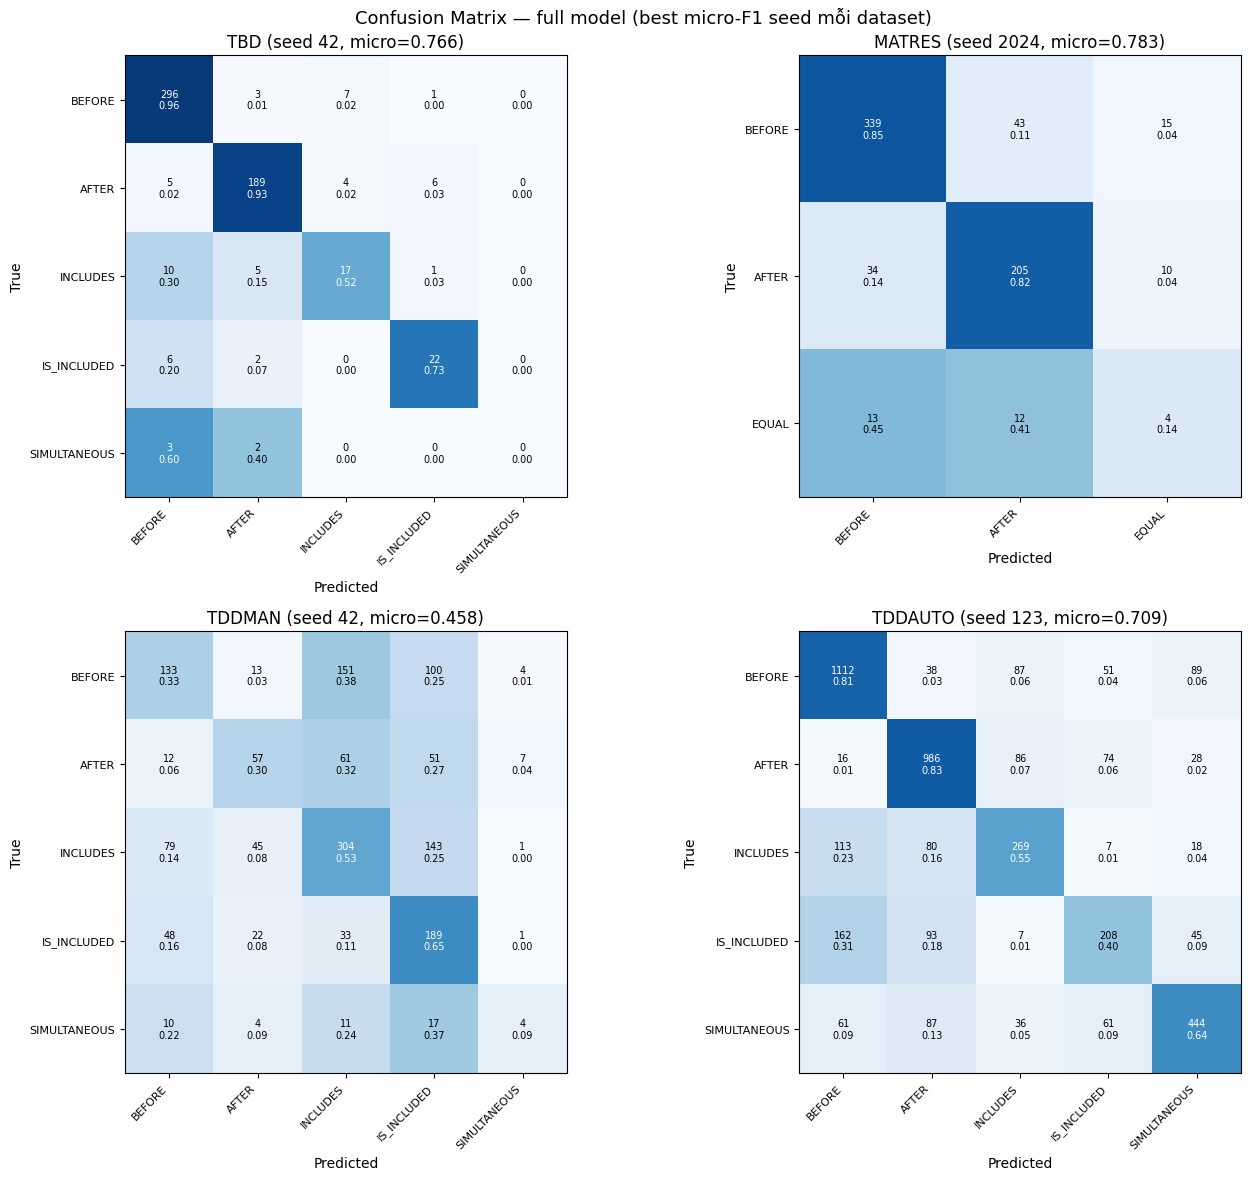

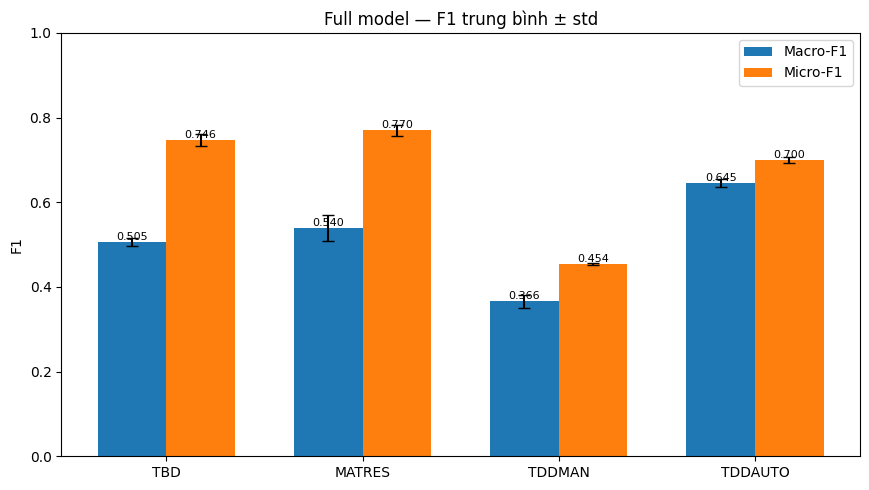

In [16]:
# 4 (hoặc ít hơn) classification report — lấy seed có micro-F1 cao nhất mỗi dataset.
for ds in DATASETS:
    br = best_run[ds]
    print(f'\n===== {ds.upper()} | best seed {br["seed"]} | '
          f'micro-F1={br["test_micro"]:.4f} macro-F1={br["test_macro"]:.4f} =====')
    print(classification_report_str(br['preds'], br['labels'], data_cache[ds]['cfg']))

# Confusion matrix (cùng best seed) — lưới thích ứng theo số dataset, chuẩn hoá theo hàng (recall).
ncol = 2 if len(DATASETS) > 1 else 1
nrow = int(np.ceil(len(DATASETS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(7 * ncol, 6 * nrow), squeeze=False)
axes = axes.ravel()
for ax, ds in zip(axes, DATASETS):
    cfg = data_cache[ds]['cfg']
    br  = best_run[ds]
    p, l = _eval_subset(br['preds'], br['labels'], cfg)
    ids   = cfg['eval_label_ids']
    names = [cfg['id2label'][i] for i in ids]
    cm  = confusion_matrix(l, p, labels=ids)
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'{ds.upper()} (seed {br["seed"]}, micro={br["test_micro"]:.3f})')
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(len(names)):
        for j in range(len(names)):
            ax.text(j, i, f'{cm[i, j]}\n{cmn[i, j]:.2f}', ha='center', va='center',
                    fontsize=7, color='white' if cmn[i, j] > 0.5 else 'black')
for ax in axes[len(DATASETS):]:           # ẩn ô thừa khi < nrow*ncol dataset
    ax.axis('off')
fig.suptitle('Confusion Matrix — full model (best micro-F1 seed mỗi dataset)', fontsize=13)
plt.tight_layout(); plt.show()

# Biểu đồ cột macro/micro-F1 (mean ± std trên các seed) cho từng dataset.
fig, ax = plt.subplots(figsize=(max(6, 2.2 * len(DATASETS)), 5))
x = np.arange(len(DATASETS)); w = 0.35
for off, metric, lab in [(-w / 2, 'test_macro', 'Macro-F1'), (w / 2, 'test_micro', 'Micro-F1')]:
    means = [df_runs[df_runs.dataset == d][metric].mean() for d in DATASETS]
    stds  = [df_runs[df_runs.dataset == d][metric].std(ddof=0) for d in DATASETS]
    bars  = ax.bar(x + off, means, w, yerr=stds, capsize=4, label=lab)
    for b, mv in zip(bars, means):
        ax.text(b.get_x() + b.get_width() / 2, mv, f'{mv:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([d.upper() for d in DATASETS])
ax.set_ylabel('F1'); ax.set_ylim(0, 1); ax.legend()
ax.set_title('Full model — F1 trung bình ± std')
plt.tight_layout(); plt.show()

## 7. Ablation Study

Mỗi case chỉ chạy **1 seed**. Công tắc `ABLATION_MODE`: `'all'` = chạy cả 4 dataset · `'single'` (mặc định) = 1 dataset đại diện · `'off'` = **không** chạy ablation (bỏ qua hoàn toàn).

Các case (so với **Full**): **− Graph** (bỏ graph propagation) · **− Relation** (bỏ nhánh `z_rel`) · **− Event** (bỏ nhánh `z_geo` Allen) · **− Align loss** (tắt `L_align`). Mỗi case bật/tắt qua cờ `abl_*` trong cfg nên kiến trúc mô hình đầy đủ không đổi.

In [17]:
# ── Cấu hình ablation ──
# ABLATION_MODE: 'all' = cả 4 dataset · 'single' = 1 dataset đại diện · 'off' = không chạy.
ABLATION_MODE   = 'single'          # 'all' | 'single' | 'off'
ABLATION_SINGLE = 'tddauto'          # dataset đại diện khi mode = 'single'
ABLATION_SEED   = 42                # mỗi case chỉ chạy 1 seed

ABLATION_CASES = {
    'Full (ref)':   {},                                # mô hình đầy đủ (đối chứng)
    '− Graph':      dict(abl_use_graph=False),         # bỏ graph propagation
    '− Relation':   dict(abl_relation_branch=False),   # bỏ nhánh z_rel
    '− Event':      dict(abl_event_branch=False),      # bỏ nhánh z_geo (Allen)
    '− Align loss': dict(abl_align_loss=False),        # tắt L_align
}

ablation_runs = []
if ABLATION_MODE == 'off':
    print('Ablation study TẮT (ABLATION_MODE="off") → bỏ qua. Đặt "single"/"all" để chạy.')
else:
    abl_datasets = ALL_DATASETS if ABLATION_MODE == 'all' else [ABLATION_SINGLE]
    for ds in abl_datasets:
        print(f'\n================  ABLATION · {ds.upper()}  ================')
        data = data_cache.get(ds) or prepare_dataset(ds)
        data_cache[ds] = data
        for name, overrides in ABLATION_CASES.items():
            cfg = build_config(ds, **overrides)
            print(f'\n--- {ds} | {name} | seed {ABLATION_SEED} ---')
            res = run_single(data, cfg, ABLATION_SEED, tag=f'{ds}|{name}', verbose=False)
            del res['model']; torch.cuda.empty_cache()
            print(f'  → macro-F1={res["test_macro"]:.4f}  micro-F1={res["test_micro"]:.4f}')
            ablation_runs.append(dict(dataset=ds, case=name,
                                      test_macro=res['test_macro'], test_micro=res['test_micro']))


================  ABLATION · TDDAUTO  ================

--- tddauto | Full (ref) | seed 42 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  → macro-F1=0.6493  micro-F1=0.7006

--- tddauto | − Graph | seed 42 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  → macro-F1=0.6480  micro-F1=0.7017

--- tddauto | − Align loss | seed 42 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  → macro-F1=0.6563  micro-F1=0.6982


=== Ablation — Micro-F1 ===


dataset,tddauto
case,
Full (ref),0.7006
− Graph,0.6902
− Relation,0.6992
− Event,0.7017
− Align loss,0.6982


=== Ablation — Macro-F1 ===


dataset,tddauto
case,
Full (ref),0.6493
− Graph,0.6355
− Relation,0.6547
− Event,0.6480
− Align loss,0.6563


=== Δ Micro-F1 so với Full (ref) ===


dataset,tddauto
case,
Full (ref),0.0000
− Graph,-0.0103
− Relation,-0.0014
− Event,0.0012
− Align loss,-0.0023


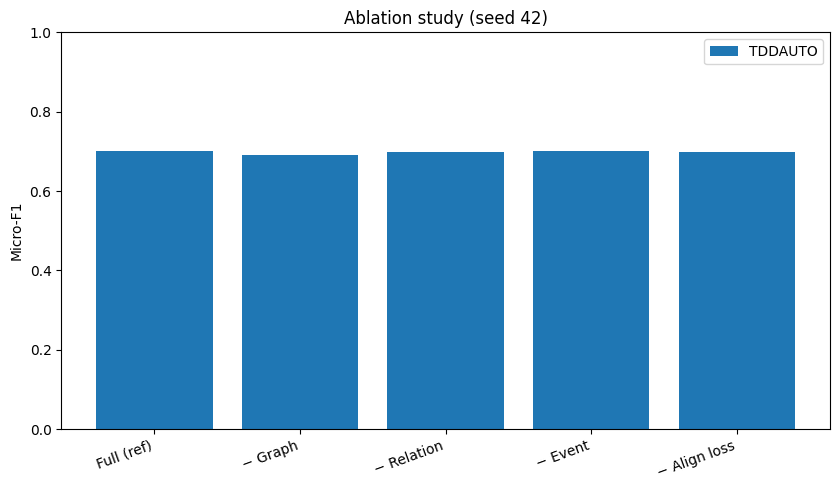

In [18]:
if not ablation_runs:
    print('Không có kết quả ablation (ABLATION_MODE="off"). Bỏ qua phần tổng hợp & biểu đồ ablation.')
else:
    abl_df = pd.DataFrame(ablation_runs)
    case_order = list(ABLATION_CASES.keys())

    pivot_micro = abl_df.pivot(index='case', columns='dataset', values='test_micro').reindex(case_order)
    pivot_macro = abl_df.pivot(index='case', columns='dataset', values='test_macro').reindex(case_order)
    print('=== Ablation — Micro-F1 ==='); display(pivot_micro.round(4))
    print('=== Ablation — Macro-F1 ==='); display(pivot_macro.round(4))

    # Δ Micro-F1 so với Full (ref): âm = thành phần đó đóng góp dương cho mô hình.
    delta = pivot_micro - pivot_micro.loc['Full (ref)']
    print('=== Δ Micro-F1 so với Full (ref) ==='); display(delta.round(4))
    abl_df.to_csv(os.path.join(BASE_CFG['save_dir'], 'ablation_runs.csv'), index=False)

    # Biểu đồ cột: Micro-F1 từng case theo dataset.
    fig, ax = plt.subplots(figsize=(max(8, 1.7 * len(case_order)), 5))
    ds_cols = list(pivot_micro.columns)
    x = np.arange(len(case_order))
    w = 0.8 / max(len(ds_cols), 1)
    for k, d in enumerate(ds_cols):
        ax.bar(x + (k - (len(ds_cols) - 1) / 2) * w, pivot_micro[d].values, w, label=d.upper())
    ax.set_xticks(x); ax.set_xticklabels(case_order, rotation=20, ha='right')
    ax.set_ylabel('Micro-F1'); ax.set_ylim(0, 1); ax.legend()
    ax.set_title(f'Ablation study (seed {ABLATION_SEED})')
    plt.tight_layout(); plt.show()

## 8. Trực quan hoá Latent Timeline

Với **mỗi dataset**, dùng **model tốt nhất** (seed micro-F1 cao nhất) và vẽ timeline cho **document có micro-F1 cao nhất** trong tập test của dataset đó. Khi `FULL_MODE='all'` sẽ có đủ **4 timeline** tương ứng 4 dataset.

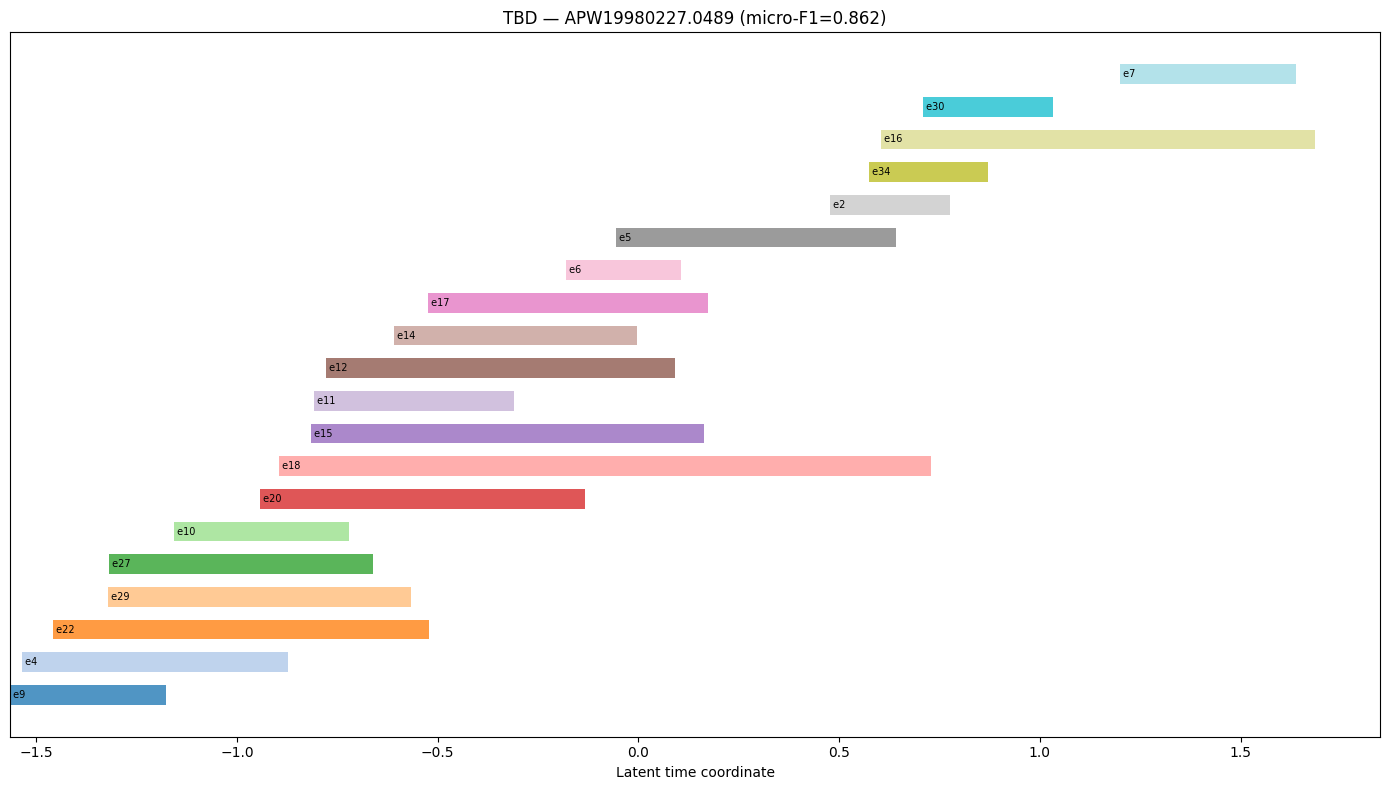

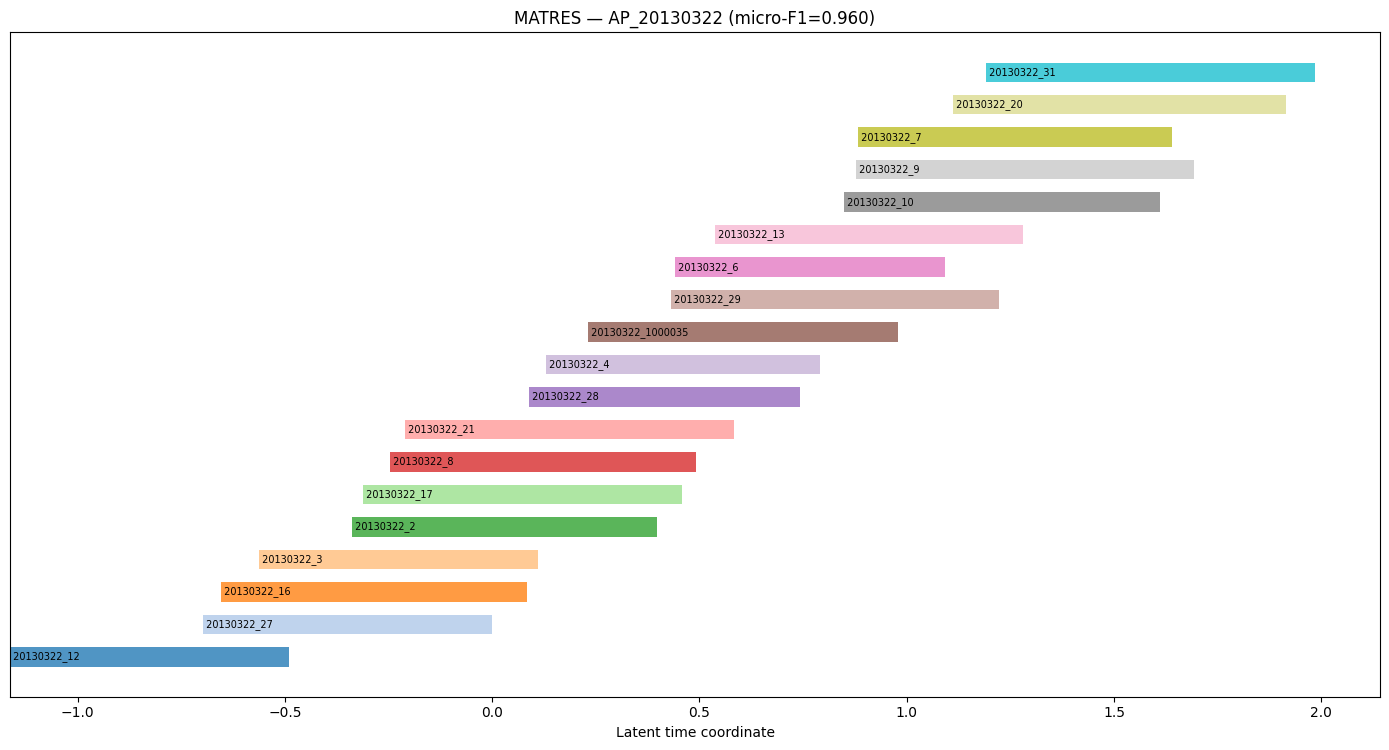

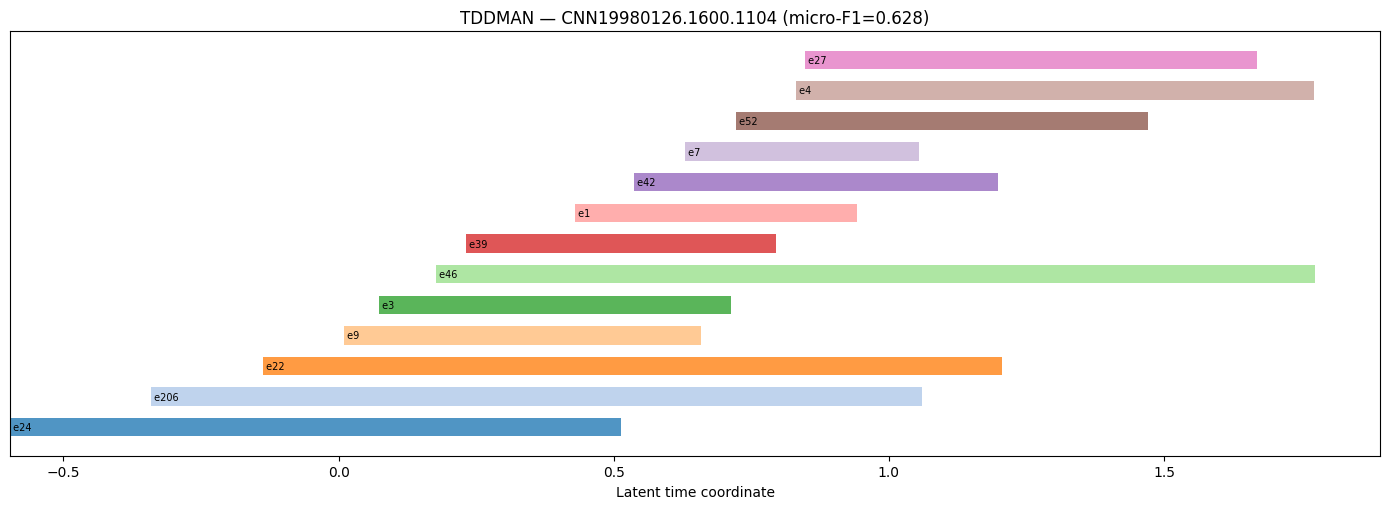

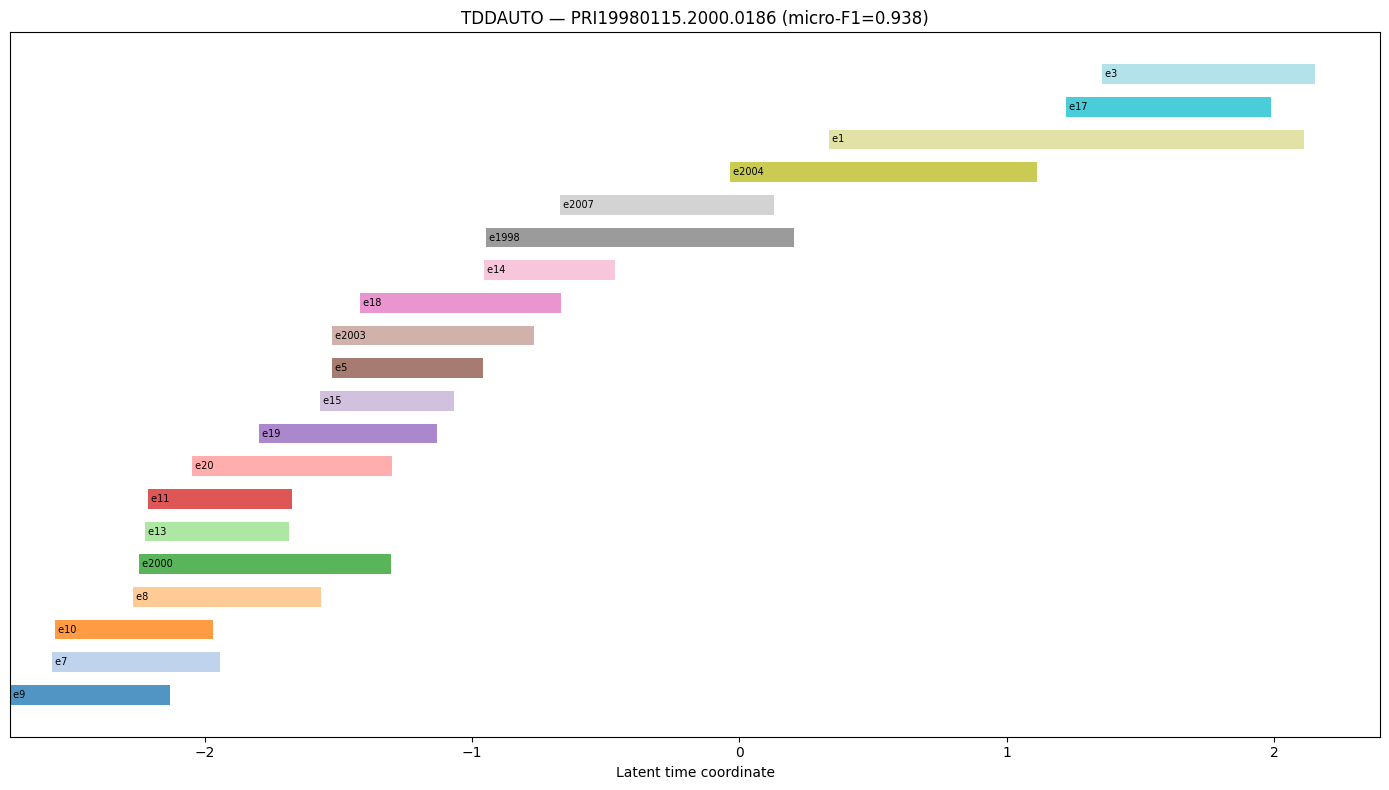

In [19]:
# ── Timeline tiềm ẩn: mỗi dataset 1 document có micro-F1 cao nhất ──────────────
import matplotlib.pyplot as plt

@torch.no_grad()
def doc_micro_f1(model, doc, cfg):
    """Micro-F1 (loại VAGUE) của riêng một document + preds, s, t."""
    logits, s, t, g, phi = model(doc, use_graph=cfg.get('abl_use_graph', True))
    preds  = logits.argmax(-1).cpu().tolist()
    labels = [p[2] for p in doc['pairs']]
    vid    = cfg['vague_id']
    mask   = [i for i, l in enumerate(labels) if l != vid]
    s_np, t_np = s.cpu().numpy(), t.cpu().numpy()
    if not mask:
        return -1.0, preds, s_np, t_np
    micro = f1_score([labels[i] for i in mask], [preds[i] for i in mask],
                     labels=cfg['eval_label_ids'], average='micro', zero_division=0)
    return micro, preds, s_np, t_np


@torch.no_grad()
def best_doc_for_dataset(model, docs, cfg, min_pairs=3):
    """Document có micro-F1 cao nhất (ưu tiên doc đủ ≥ min_pairs cặp; tie-break theo số cặp)."""
    model.eval()
    scored = [(doc_micro_f1(model, doc, cfg)[0], len(doc['pairs']), doc) for doc in docs]
    rich = [x for x in scored if x[1] >= min_pairs] or scored
    return max(rich, key=lambda x: (x[0], x[1]))[2]


@torch.no_grad()
def plot_latent_timeline(model, doc, cfg, ax=None, top_k=20):
    model.eval()
    micro, preds, s, t = doc_micro_f1(model, doc, cfg)
    event_ids = doc['event_ids']
    order = np.argsort(s)[:top_k]                       # sớm → muộn theo start s
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(14, max(4, len(order) * 0.4)))
    colors = plt.cm.tab20.colors
    for row, idx in enumerate(order):
        eid = event_ids[idx].split('_', 1)[1]           # bỏ tiền tố doc_id
        ax.barh(row, t[idx] - s[idx], left=s[idx], height=0.6,
                color=colors[row % len(colors)], alpha=0.78)
        ax.text(s[idx], row, f' {eid}', va='center', fontsize=7)
    ax.set_xlabel('Latent time coordinate'); ax.set_yticks([])
    ax.set_title(f'{cfg["dataset"].upper()} — {doc["doc_id"]} (micro-F1={micro:.3f})')
    if own:
        plt.tight_layout(); plt.show()


timeline_docs = {}   # dataset → document được chọn (dùng lại nếu cần)
for ds in best_run:
    cfg   = data_cache[ds]['cfg']
    model = best_run[ds]['model'].to(DEVICE)
    doc   = best_doc_for_dataset(model, data_cache[ds]['test_docs'], cfg)
    timeline_docs[ds] = doc
    plot_latent_timeline(model, doc, cfg)
    best_run[ds]['model'].to('cpu'); torch.cuda.empty_cache()

## 9. Phân tích phân bố tọa độ tiềm ẩn (test set)

Chạy **model tốt nhất của mỗi dataset** trên **toàn bộ tập test** rồi thu các tọa độ thời gian tiềm ẩn `s` (start), `t` (end) và độ dài interval `d = t − s` cho mọi event, nhằm so sánh đặc trưng hình học mô hình sinh ra giữa các dataset.

In [20]:
# ── Thu tọa độ tiềm ẩn trên test set của từng dataset ──────────────────────────
@torch.no_grad()
def collect_latent_stats(model, docs, cfg):
    """Gom (s, t, d) theo event + nhãn dự đoán theo cặp trên toàn tập test."""
    model.eval()
    S, T, D, doc_mean_d, pred_labels = [], [], [], [], []
    for doc in docs:
        logits, s, t, g, phi = model(doc, use_graph=cfg.get('abl_use_graph', True))
        s = s.cpu().numpy(); t = t.cpu().numpy()
        S.append(s); T.append(t); D.append(t - s)
        doc_mean_d.append((t - s).mean())
        pred_labels.extend(logits.argmax(-1).cpu().tolist())
    return dict(s=np.concatenate(S), t=np.concatenate(T), d=np.concatenate(D),
                doc_mean_d=np.array(doc_mean_d), pred_labels=np.array(pred_labels))

latent_stats = {}
for ds in best_run:
    cfg   = data_cache[ds]['cfg']
    model = best_run[ds]['model'].to(DEVICE)
    latent_stats[ds] = collect_latent_stats(model, data_cache[ds]['test_docs'], cfg)
    best_run[ds]['model'].to('cpu'); torch.cuda.empty_cache()

# Bảng thống kê mô tả s, t, d theo dataset.
stat_rows = []
for ds, st in latent_stats.items():
    for name, arr in [('s (start)', st['s']), ('t (end)', st['t']), ('d = t−s', st['d'])]:
        stat_rows.append(dict(Dataset=ds.upper(), Coord=name,
                              Mean=arr.mean(), Std=arr.std(),
                              Min=arr.min(), Q25=np.percentile(arr, 25),
                              Median=np.median(arr), Q75=np.percentile(arr, 75),
                              Max=arr.max()))
coord_stat_df = pd.DataFrame(stat_rows).round(4)
print('=== Thống kê mô tả tọa độ tiềm ẩn theo dataset ==='); display(coord_stat_df)
coord_stat_df.to_csv(os.path.join(BASE_CFG['save_dir'], 'latent_coord_stats.csv'), index=False)

=== Thống kê mô tả tọa độ tiềm ẩn theo dataset ===


,Dataset,Coord,Mean,Std,Min,Q25,Median,Q75,Max
0,TBD,s (start),0.3666,0.9386,-1.8366,-0.2712,0.3583,1.1714,2.0748
1,TBD,t (end),1.0744,0.9641,-1.3010,0.4488,1.1091,1.9053,2.8474
2,TBD,d = t−s,0.7078,0.3530,0.2841,0.4694,0.6217,0.8081,2.3321
3,MATRES,s (start),0.1334,0.6545,-1.2664,-0.3382,0.1027,0.6833,1.5342
4,MATRES,t (end),0.8932,0.6671,-0.6284,0.4187,0.8858,1.4569,2.2211
5,MATRES,d = t−s,0.7599,0.0544,0.6072,0.7225,0.7565,0.7988,0.9303
6,TDDMAN,s (start),0.2925,0.6086,-1.2457,-0.1452,0.3287,0.8145,1.5684
7,TDDMAN,t (end),1.1421,0.6688,-0.6744,0.6548,1.2746,1.6868,2.5381
8,TDDMAN,d = t−s,0.8497,0.3959,0.3439,0.5646,0.7305,1.0505,2.0962
9,TDDAUTO,s (start),0.2078,1.5802,-2.9521,-0.9558,0.4811,1.2083,2.8339


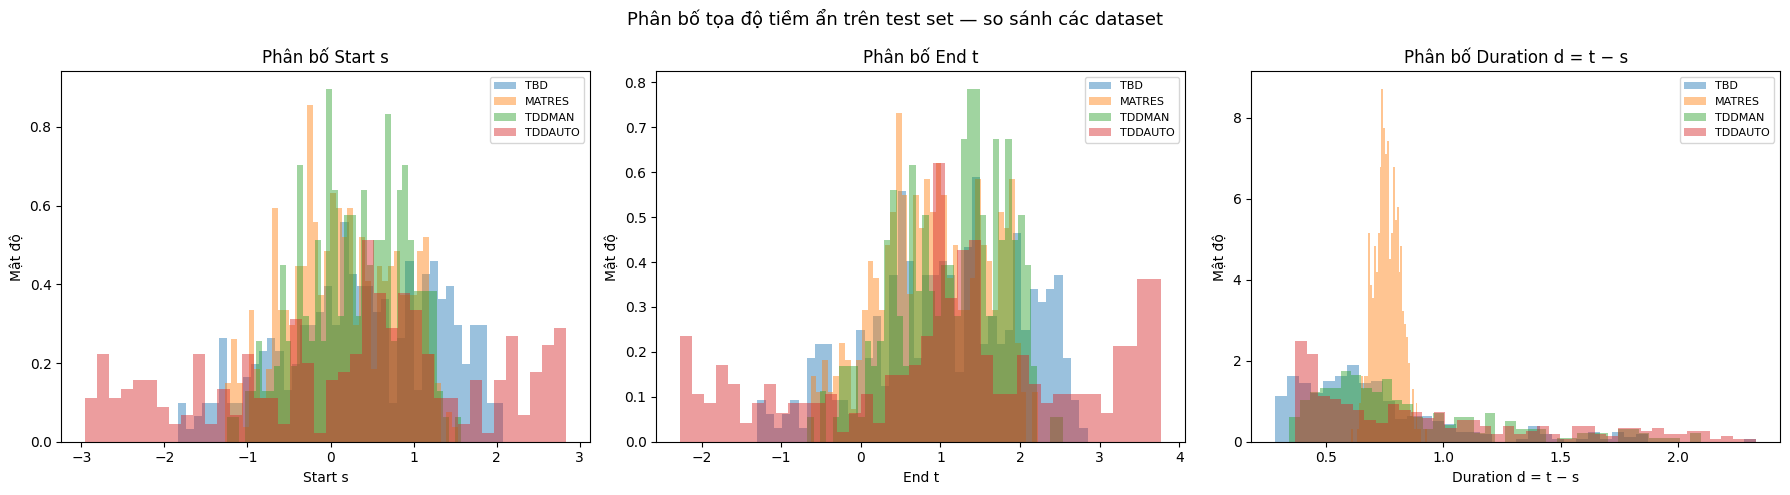

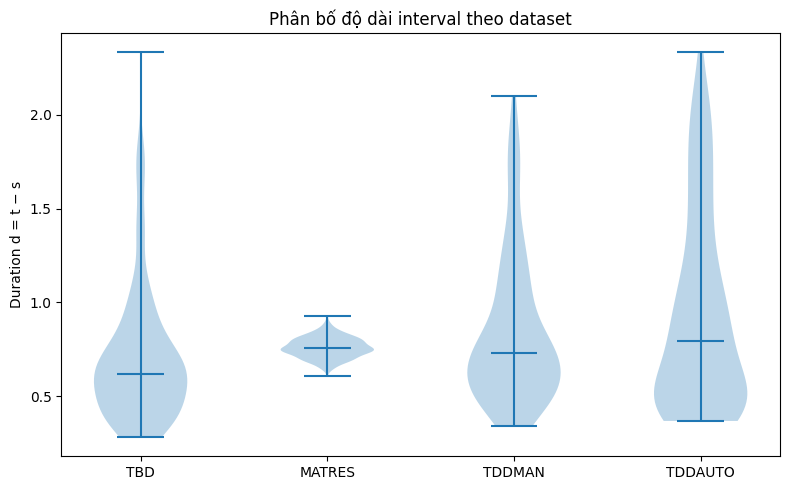

In [21]:
# ── Histogram phân bố s, t, d (chồng các dataset) + violin độ dài interval ─────
ds_list = list(latent_stats.keys())
palette = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, key, title in zip(axes, ['s', 't', 'd'],
                          ['Start s', 'End t', 'Duration d = t − s']):
    for k, ds in enumerate(ds_list):
        ax.hist(latent_stats[ds][key], bins=40, density=True, alpha=0.45,
                color=palette[k % len(palette)], label=ds.upper())
    ax.set_title(f'Phân bố {title}'); ax.set_xlabel(title); ax.set_ylabel('Mật độ')
    ax.legend(fontsize=8)
fig.suptitle('Phân bố tọa độ tiềm ẩn trên test set — so sánh các dataset', fontsize=13)
plt.tight_layout(); plt.show()

# Violin độ dài interval d theo dataset (so sánh độ "dài/ngắn" sự kiện mô hình sinh ra).
fig, ax = plt.subplots(figsize=(max(6, 2 * len(ds_list)), 5))
ax.violinplot([latent_stats[ds]['d'] for ds in ds_list], showmedians=True)
ax.set_xticks(range(1, len(ds_list) + 1)); ax.set_xticklabels([d.upper() for d in ds_list])
ax.set_ylabel('Duration d = t − s'); ax.set_title('Phân bố độ dài interval theo dataset')
plt.tight_layout(); plt.show()

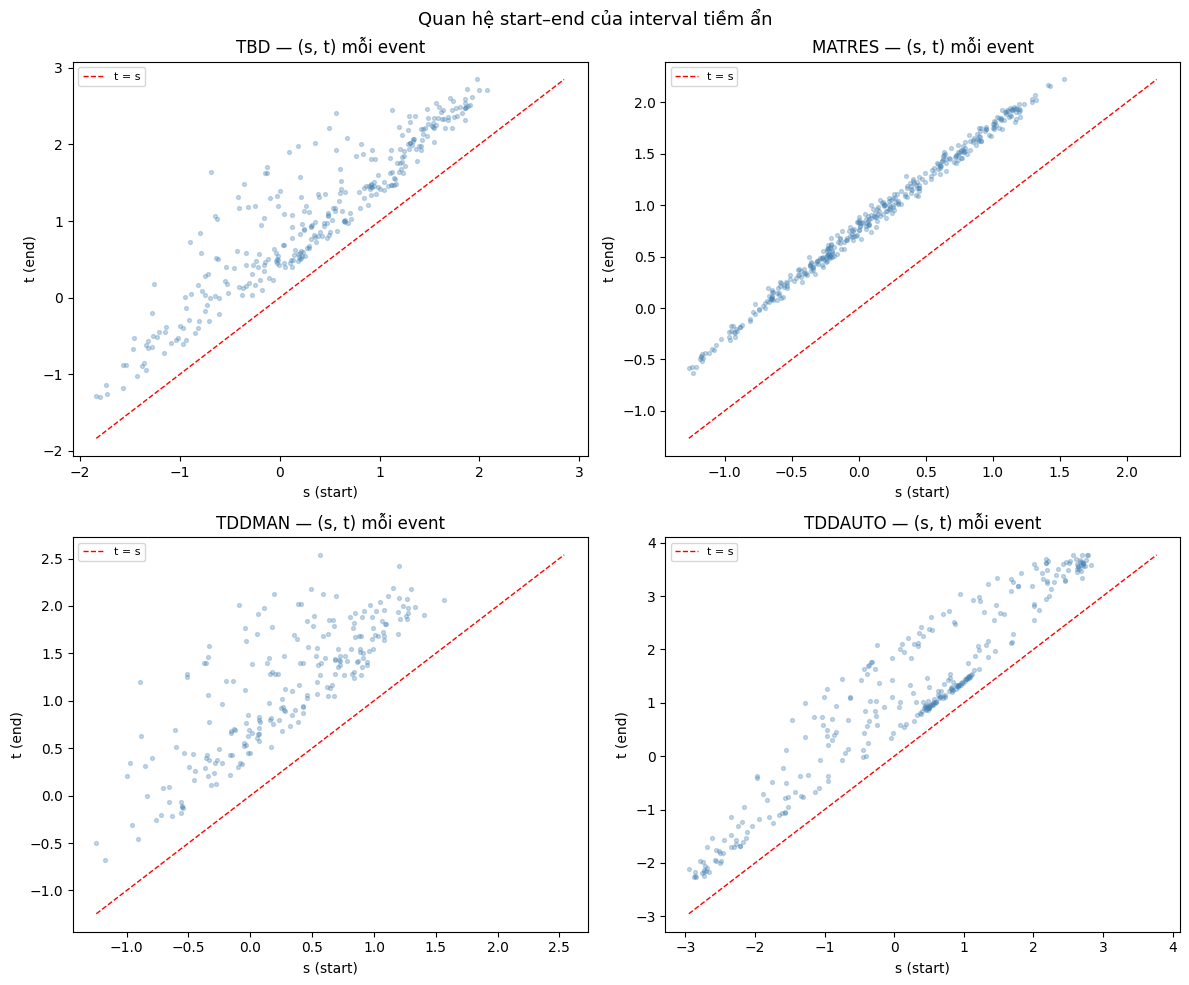

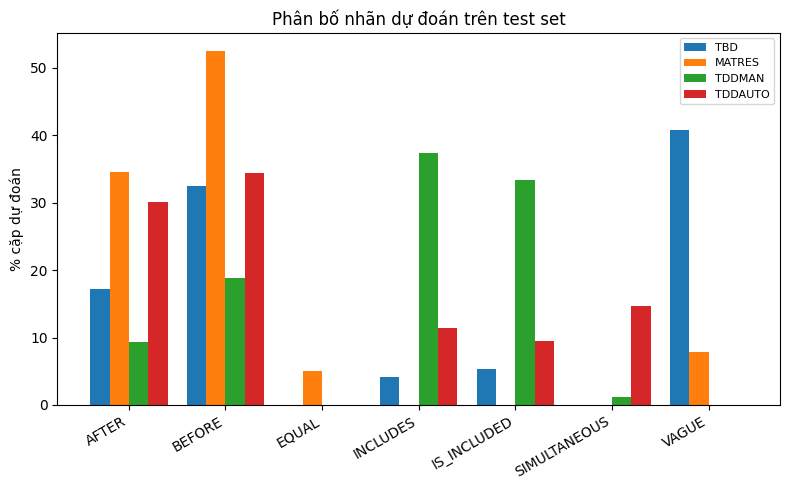

In [22]:
# ── Scatter (s, t) theo dataset + phân bố nhãn dự đoán ─────────────────────────
ncol = 2 if len(ds_list) > 1 else 1
nrow = int(np.ceil(len(ds_list) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(6 * ncol, 5 * nrow), squeeze=False)
axes = axes.ravel()
for ax, ds in zip(axes, ds_list):
    st = latent_stats[ds]
    ax.scatter(st['s'], st['t'], s=8, alpha=0.3, color='steelblue')
    lo = min(st['s'].min(), st['t'].min()); hi = max(st['s'].max(), st['t'].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='t = s')
    ax.set_xlabel('s (start)'); ax.set_ylabel('t (end)')
    ax.set_title(f'{ds.upper()} — (s, t) mỗi event'); ax.legend(fontsize=8)
for ax in axes[len(ds_list):]:
    ax.axis('off')
fig.suptitle('Quan hệ start–end của interval tiềm ẩn', fontsize=13)
plt.tight_layout(); plt.show()

# Phân bố nhãn dự đoán (tỉ lệ %) theo dataset — so sánh thiên lệch lớp giữa các dataset.
fig, ax = plt.subplots(figsize=(max(8, 2 * len(ds_list)), 5))
all_label_names = sorted({n for ds in ds_list for n in data_cache[ds]['cfg']['labels']})
x = np.arange(len(all_label_names)); w = 0.8 / max(len(ds_list), 1)
for k, ds in enumerate(ds_list):
    cfg = data_cache[ds]['cfg']; pl = latent_stats[ds]['pred_labels']
    frac = [100 * np.mean(pl == cfg['label_map'][n]) if n in cfg['label_map'] else 0.0
            for n in all_label_names]
    ax.bar(x + (k - (len(ds_list) - 1) / 2) * w, frac, w, label=ds.upper())
ax.set_xticks(x); ax.set_xticklabels(all_label_names, rotation=30, ha='right')
ax.set_ylabel('% cặp dự đoán'); ax.set_title('Phân bố nhãn dự đoán trên test set')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()